In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                       # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                             # 텐서플로우 lib


from tensorflow.keras import layers, models

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential                   
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지


np.random.seed(42)
tf.random.set_seed(42)

In [16]:
# 데이터 가져오기 (32x32 이미지 크기)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()


# cnn 입력 형태에 맞게 채널 차원을 reshape
y_train = y_train.reshape(-1)    # shape (30000,1)  --> (30000)
y_test = y_test.reshape(-1)      # shape (10000,1)  --> (10000)

(10000, 32, 32, 3)

In [17]:
# 픽셀값 0~1 범위로 정규화   
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [19]:
# 모델 정의
model = models.Sequential([
    #data_augmentation,

    # 첫 번째 CNN layer
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),   # 컬러 이미지 입력
    layers.BatchNormalization(),                #  학습 안정화 및 수렴속도 향상
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),                   # 특징 추출해서 특징맵 크기를 감소
    layers.Dropout(0.5),

    # 두 번째 CNN layer
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.5),

    # 세 번째 CNN layer
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Fully Connected layer 
    layers.Flatten(),                               # 2D --> 1D 벡터로 변환
    layers.Dense(256),                              # 256개의 뉴런으로 학습
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    # 출력층
    layers.Dense(10, activation='softmax')          # 10개 클래스에 대한 확률 출력
])

model.summary()

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# 모델 학습
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 75ms/step - accuracy: 0.3995 - loss: 1.7064 - val_accuracy: 0.1905 - val_loss: 3.5929
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.5160 - loss: 1.3451 - val_accuracy: 0.1808 - val_loss: 3.2689
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.5699 - loss: 1.2051 - val_accuracy: 0.3267 - val_loss: 2.3978
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6053 - loss: 1.1110 - val_accuracy: 0.3395 - val_loss: 2.4382
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.6323 - loss: 1.0318 - val_accuracy: 0.3971 - val_loss: 2.0415
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6527 - loss: 0.9783 - val_accuracy: 0.4484 - val_loss: 1.8750
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.6721 - loss: 0.9282 - val_accuracy: 0.5999 - val_loss: 1.2350
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6843 - loss: 0.8949 - 

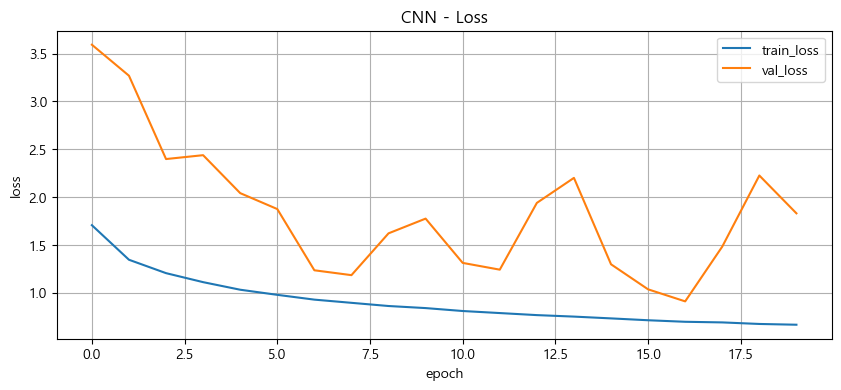

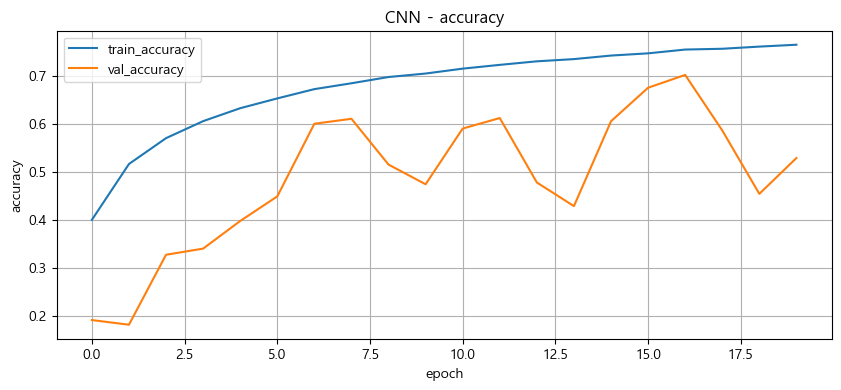

In [22]:
# 결과 시각화

# 학습 손실 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)


# 학습 정확도 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


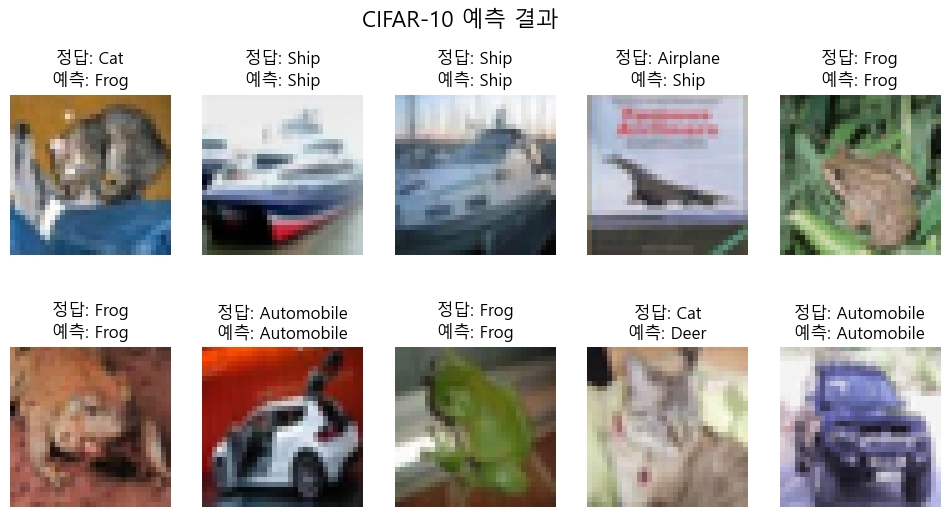

In [25]:
# 10개 이미지 예측 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])                               
    plt.title(f"정답: {class_names[y_test[i]]}\n예측: {class_names[y_pred[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결과", fontsize=16)
plt.show()

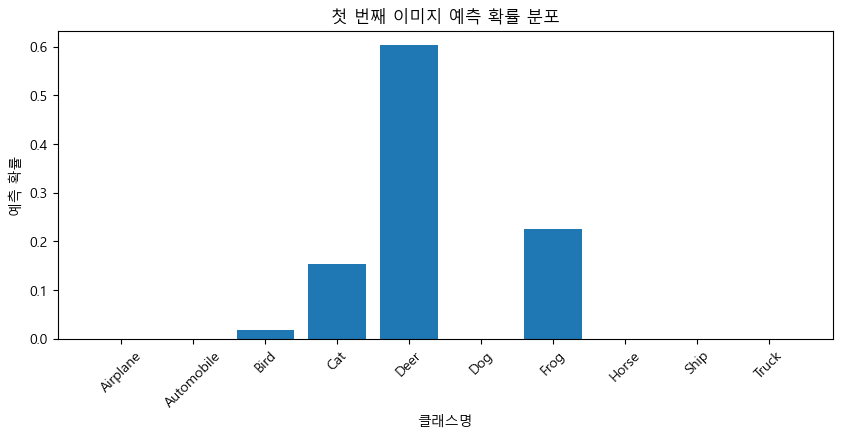

In [31]:
# 개별 이미지 클래스 별 예측 확률 확인
plt.figure(figsize=(10,4))
plt.bar(range(10), y_prob[8])
plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("클래스명")
plt.ylabel("예측 확률")
plt.title("첫 번째 이미지 예측 확률 분포")
plt.show()
